In [1]:
from pathlib import Path
import os


# --- Helper: choose between macOS-style and Windows-style roots ---
def project_path(mac_path_str, win_path_str):
    mac_p = Path(mac_path_str)
    win_p = Path(win_path_str)
    if mac_p.exists():
        return mac_p
    elif win_p.exists():
        return win_p
    else:
        # Neither exists; return mac version but warn
        print(f"WARNING: Neither {mac_p} nor {win_p} exists on this system.")
        return mac_p


project_path_set = project_path(
    "/Users/kaankeskin/projects/FrequencySliding/",
    "C:/Users/kaank/OneDrive/Belgeler/GitHub/FrequencySliding/"
)

# Set the working directory
os.chdir(project_path_set)

# Check current working directory
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\kaank\OneDrive\Belgeler\GitHub\FrequencySliding


In [2]:
import pandas as pd
df_all=pd.read_csv("./data/output/tau_perROI.csv",index_col=0)
print(df_all)

                       0         1         2         3         4         5  \
subject                                                                      
sub-1.results   0.146558  0.048846  0.085489  0.093133  0.463886  0.295246   
sub-10.results  0.082327  0.080025  0.079782  0.082260  0.079061  0.090297   
sub-11.results       NaN  0.081489  0.081203  0.269492       NaN  0.286235   
sub-12.results  0.086344  0.079511       NaN  0.084085       NaN  0.317419   
sub-13.results  0.454147       NaN  0.016508       NaN       NaN  0.098159   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  0.614633  0.100258  0.106817  0.423392  0.387417  0.364261   
sub-72.results       NaN  0.039514  0.081425  0.085008       NaN  0.082693   
sub-73.results  0.081842  0.077588       NaN  0.077936  0.081009       NaN   
sub-74.results  0.082971  0.082736  0.079743  0.081706  0.077937  0.076852   
sub-75.results  0.076698  0.080296  0.080836  0.078113  0.082494

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
ctrl_path = Path(r"./data/raw")
ctrl_csv = ctrl_path / "controlregions.csv"

# --- Read CSV ---
# We'll not assume headers; we'll read and rename first two cols defensively.
ctrl_df = pd.read_csv(ctrl_csv)

# If the file has no header row and just two columns, uncomment:
# ctrl_df = pd.read_csv(ctrl_csv, header=None, names=["transmodal", "unimodal"])

# Ensure we have at least two columns
if ctrl_df.shape[1] < 2:
    raise ValueError("controlregions.csv must have at least two columns (transmodal, unimodal).")

# Normalize column names (optional but convenient)
ctrl_df = ctrl_df.rename(columns=lambda c: str(c).strip().lower())

# Try to find columns by name; fall back to positional
trans_col = next((c for c in ctrl_df.columns if "trans" in c), ctrl_df.columns[0])
uni_col   = next((c for c in ctrl_df.columns if "uni" in c),   ctrl_df.columns[1])

transmask_raw = ctrl_df[trans_col].to_numpy()
unimask_raw   = ctrl_df[uni_col].to_numpy()

# --- Coerce to boolean masks ---
# Treat nonzero & non-null as True
transmask = np.asarray(transmask_raw, dtype=float)
unimask   = np.asarray(unimask_raw, dtype=float)

# If any NaNs, treat as 0
transmask = np.nan_to_num(transmask, nan=0.0)
unimask   = np.nan_to_num(unimask,   nan=0.0)

transmask_bool = transmask.astype(bool)
unimask_bool   = unimask.astype(bool)

# --- Check mask lengths vs df_all columns ---
n_roi_mask = len(transmask_bool)
n_roi_df   = df_all.shape[1]

if n_roi_mask != n_roi_df:
    raise ValueError(
        f"Mask length ({n_roi_mask}) != number of ROI columns in df_all ({n_roi_df}). "
        "We need a mapping or confirmation of ROI order."
    )

# --- Compute subject means across masked ROIs ---
# df_all: subjects × ROIs
tau_transmodal = df_all.loc[:, transmask_bool].mean(axis=1, skipna=True)
tau_unimodal   = df_all.loc[:, unimask_bool].mean(axis=1, skipna=True)

# --- Append to df_all ---
df_all = df_all.copy()
df_all["tau_transmodal"] = tau_transmodal
df_all["tau_unimodal"]   = tau_unimodal

print(df_all)



                       0         1         2         3         4         5  \
subject                                                                      
sub-1.results   0.146558  0.048846  0.085489  0.093133  0.463886  0.295246   
sub-10.results  0.082327  0.080025  0.079782  0.082260  0.079061  0.090297   
sub-11.results       NaN  0.081489  0.081203  0.269492       NaN  0.286235   
sub-12.results  0.086344  0.079511       NaN  0.084085       NaN  0.317419   
sub-13.results  0.454147       NaN  0.016508       NaN       NaN  0.098159   
...                  ...       ...       ...       ...       ...       ...   
sub-71.results  0.614633  0.100258  0.106817  0.423392  0.387417  0.364261   
sub-72.results       NaN  0.039514  0.081425  0.085008       NaN  0.082693   
sub-73.results  0.081842  0.077588       NaN  0.077936  0.081009       NaN   
sub-74.results  0.082971  0.082736  0.079743  0.081706  0.077937  0.076852   
sub-75.results  0.076698  0.080296  0.080836  0.078113  0.082494

In [4]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. Load BP sheet (Excel): has SubjectID, Total Score, Age, Sex
# ------------------------------------------------------------------
bp_subj = pd.read_excel(
    r"./data/raw/BDI_ThreeFactor_MultiSubject.xlsx"
)

# Standardize column names just in case
bp_subj = bp_subj.rename(columns=lambda c: str(c).strip())

# Rename Total Score -> BDI; keep needed columns
bp_use = (
    bp_subj.rename(columns={"Total Score": "BDI"})[["SubjectID", "BDI", "Age", "Sex"]]
    .assign(Group="BP")
)

# ------------------------------------------------------------------
# 2. Load HC participants slice from TSV and drop exclusions
# ------------------------------------------------------------------
df = pd.read_csv(r"E:/BIDS/participants.tsv", sep="\t")

# R slice(35:70) => pandas iloc[34:70] (sub-35..sub-70 inclusive in R)
df_slice = df.iloc[34:70].copy()

exclude_ids = ["sub-54", "sub-39", "sub-58"]
hc_subj = df_slice.loc[~df_slice["participant_id"].isin(exclude_ids)].copy()

# Number of HC subjects kept
n = len(hc_subj)

# ------------------------------------------------------------------
# 3. Build renumbered HC ID list starting at 43
# ------------------------------------------------------------------
start_id = 43
hc_ids_renum = [f"sub-{start_id + i}" for i in range(n)]

# Create HC BDI/demographics DataFrame with renumbered IDs
hc_bdi_renum_df = pd.DataFrame({
    "SubjectID": hc_ids_renum,
    "BDI": pd.to_numeric(hc_subj["BDI"], errors="coerce"),
    "Age": pd.to_numeric(hc_subj["Age"], errors="coerce"),
    "Sex": pd.to_numeric(hc_subj["Sex"], errors="coerce"),
    "Group": "HC",   # one value broadcast to all rows
})

# ------------------------------------------------------------------
# 4. Combine BP + HC into one BDI/demographics table
# ------------------------------------------------------------------
bdi_df = pd.concat([bp_use, hc_bdi_renum_df], axis=0, ignore_index=True)

# Ensure BDI numeric
bdi_df["BDI"] = pd.to_numeric(bdi_df["BDI"], errors="coerce")

# ------------------------------------------------------------------
# 5. Prepare df_all imaging data
#     (Assumes df_all already exists & MF_transmodal / MF_unimodal arrays ready)
# ------------------------------------------------------------------
df_all = df_all.copy()

# Add MF columns if not already present
df_all["tau_transmodal"] = tau_transmodal
df_all["tau_unimodal"]   = tau_unimodal

# Add clean SubjectID (strip ".results")
df_all["SubjectID"] = df_all.index.to_series().str.replace(".results", "", regex=False)

# ------------------------------------------------------------------
# 6. Merge BDI + Age + Sex into df_all by SubjectID
# ------------------------------------------------------------------
df_all = df_all.merge(
    bdi_df,                # has SubjectID, BDI, Age, Sex
    on="SubjectID",
    how="left",
    validate="m:1"         # one demographic row per SubjectID expected
)

# ------------------------------------------------------------------
# 7. Final metrics table with Age & Sex at the end
# ------------------------------------------------------------------
df_metrics = df_all.loc[:, ["SubjectID", "Group","BDI", "tau_transmodal", "tau_unimodal", "Age", "Sex"]].reset_index(drop=True)

print(df_metrics.head())
print(df_metrics.tail())
print("Shape:", df_metrics.shape)
print("Missing BDI:", df_metrics["BDI"].isna().sum())


  SubjectID Group   BDI  tau_transmodal  tau_unimodal   Age  Sex
0     sub-1    BP   8.0        0.212953      0.197001  56.0  2.0
1    sub-10    BP  30.0        0.114225      0.097400  26.0  2.0
2    sub-11    BP  44.0        0.164145      0.102401  54.0  1.0
3    sub-12    BP  38.0        0.202743      0.084583  40.0  1.0
4    sub-13    BP  22.0        0.376999      0.242276  52.0  2.0
   SubjectID Group  BDI  tau_transmodal  tau_unimodal   Age  Sex
66    sub-71    HC  2.0        0.098327      0.163969  22.0  2.0
67    sub-72    HC  3.0        0.093238      0.080251  31.0  1.0
68    sub-73    HC  0.0        0.085748      0.081003  28.0  1.0
69    sub-74    HC  8.0        0.106456      0.082558  46.0  2.0
70    sub-75    HC  1.0        0.080446      0.078279  20.0  2.0
Shape: (71, 7)
Missing BDI: 1


In [5]:
# Longer format for the analysis 
import pandas as pd

# Assuming your DataFrame is called `df`
df_long = pd.melt(
    df_metrics,
    id_vars=["SubjectID", "Group", "BDI", "Age", "Sex"],  # columns to keep
    value_vars=["tau_transmodal", "tau_unimodal"],        # columns to unpivot
    var_name="region", 
    value_name="value"
)

def zscore(s): return (s - s.mean(skipna=True)) / s.std(ddof=0,skipna=True)

# Clean up the region names if needed
df_long["region"] = df_long["region"].str.replace("tau_", "").astype("category")
df_long["Sex"] = df_long["Sex"].astype("category")
df_long["Group"] = df_long["Group"].astype("category")

df_long["z_value"] = zscore(df_long["value"])
df_long["z_age"] = zscore(df_long["Age"])

print(df_long)


    SubjectID Group   BDI   Age  Sex      region     value   z_value     z_age
0       sub-1    BP   8.0  56.0  2.0  transmodal  0.212953  0.525675  1.715244
1      sub-10    BP  30.0  26.0  2.0  transmodal  0.114225 -0.683714 -1.035863
2      sub-11    BP  44.0  54.0  1.0  transmodal  0.164145 -0.072217  1.531837
3      sub-12    BP  38.0  40.0  1.0  transmodal  0.202743  0.400602  0.247987
4      sub-13    BP  22.0  52.0  2.0  transmodal  0.376999  2.535188  1.348430
..        ...   ...   ...   ...  ...         ...       ...       ...       ...
137    sub-71    HC   2.0  22.0  2.0    unimodal  0.163969 -0.074365 -1.402677
138    sub-72    HC   3.0  31.0  1.0    unimodal  0.080251 -1.099884 -0.577345
139    sub-73    HC   0.0  28.0  1.0    unimodal  0.081003 -1.090678 -0.852456
140    sub-74    HC   8.0  46.0  2.0    unimodal  0.082558 -1.071624  0.798208
141    sub-75    HC   1.0  20.0  2.0    unimodal  0.078279 -1.124041 -1.586084

[142 rows x 9 columns]


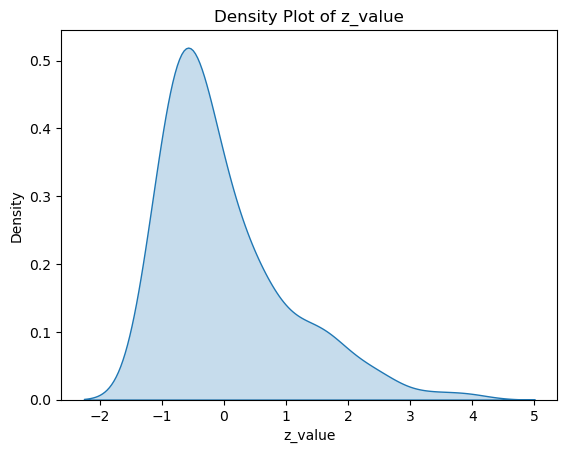

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_long, x="z_value", fill=True)
plt.title("Density Plot of z_value")
plt.xlabel("z_value")
plt.ylabel("Density")
plt.show()

Below is bambi API. However I think it is not that intuitive, it was hard to pass priors to the model. Also I got sus. Contunied to the PyMC below.

cvm


Sampling: [Group, Intercept, Sex, region, region:Group, sigma, z_age, z_value]


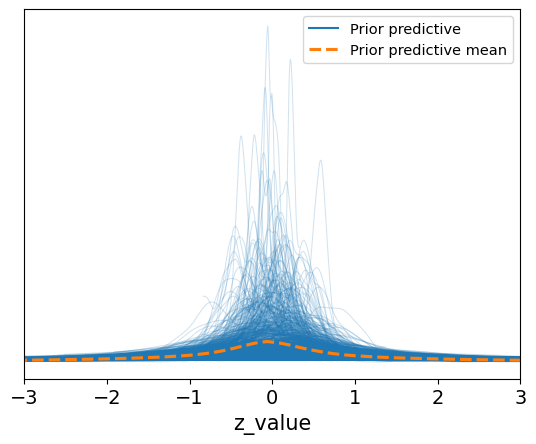

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, region, Group, region:Group, z_age, Sex]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 36 seconds.


In [55]:
#import os
#os.environ["PYTENSOR_FLAGS"] = "mode=FAST_RUN,linker=py,cxx="
import pytensor
print(pytensor.config.linker)

import arviz as az
import bambi as bmb
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import xarray as xr
 

priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=0.25),
    "region": bmb.Prior("Normal", mu=0, sigma=0.1),
    "Group": bmb.Prior("Normal", mu=0, sigma=0.1),
    "region:Group": bmb.Prior("Normal", mu=0, sigma=0.1),
    "z_age": bmb.Prior("Normal", mu=0, sigma=0.1),
    "Sex": bmb.Prior("Normal", mu=0, sigma=0.1),
    #"1|SubjectID": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=0.5)),
    "sigma": bmb.Prior("Exponential", lam=0.5)
}

model = bmb.Model(
    "z_value ~ region * Group + z_age + Sex",
    df_long,
    priors=priors,
    family="gaussian"
)
model.build()
model
#for name, term in model.components["mu"].terms.items():
#    print(f"{name}: {term.prior}")


prior_predictive = model.prior_predictive(draws=1000)
az.plot_ppc(prior_predictive, group="prior", num_pp_samples=1000, kind="kde")
# Set x-axis limits
plt.xlim(-3, 3)  # Adjust limits based on your data range
plt.show()
fitted = model.fit(draws=2000, tune=2000, chains=4, priors=priors, cores=4, target_accept=0.9, random_seed=123)

In [56]:
import arviz as az
import pymc as pm

az.summary(fitted, hdi_prob=0.95)

#model.predict(idata=fitted, kind="response")
#fitted
#az.plot_ppc(fitted);
#az.plot_ppc(idata_with_pp);
#az.plot_ppc(idata_with_pp, group="posterior", kind="kde", num_pp_samples=100)
#plt.show()


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,1.013,0.061,0.902,1.136,0.001,0.001,11731.0,5836.0,1.0
Intercept,0.020,0.121,-0.231,0.249,0.001,0.001,12081.0,6536.0,1.0
region[unimodal],-0.010,0.086,-0.185,0.156,0.001,0.001,12878.0,6351.0,1.0
Group[HC],-0.022,0.087,-0.189,0.150,0.001,0.001,13297.0,6084.0,1.0
"region:Group[unimodal, HC]",0.010,0.088,-0.169,0.181,0.001,0.001,10772.0,6626.0,1.0
z_age,0.031,0.063,-0.096,0.151,0.001,0.001,12145.0,6521.0,1.0
Sex[2.0],-0.010,0.090,-0.186,0.168,0.001,0.001,13025.0,6625.0,1.0


In [30]:
import pymc as pm
import pytensor.tensor as pt
import numpy as np
import pandas as pd
import patsy

# --- Build model matrix ---
y, X = patsy.dmatrices("z_value ~ region * Group + z_age + Sex", df_long, return_type="dataframe")

# Remove intercept column from X (PyMC handles it separately)
X_noint = X.iloc[:, 1:]
term_names = X_noint.columns.tolist()
X_array = X_noint.to_numpy()

# Outcome
y_array = y.squeeze().to_numpy()

# Group indexing (for hierarchical intercept)
group_idx, group_names = pd.factorize(df_long["Group"])

# Set coords
coords = {
    "obs": np.arange(len(df_long)),
    "group": group_names.tolist(),
    "term": term_names
}

with pm.Model(coords=coords) as model:

    # --- Hyperpriors for group intercepts ---
    mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=0.5)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)

    alpha_raw = pm.Normal("alpha_raw", mu=0, sigma=1, dims="group")
    alpha = pm.Deterministic("alpha", mu_alpha + sigma_alpha * alpha_raw, dims="group")

    # Intercept per observation
    intercept = alpha[group_idx]

    # --- Slopes ---
    b = pm.Normal("b", mu=0, sigma=0.25, dims="term")
    mu = intercept + pt.dot(X_array, b)

    # --- Residual SD ---
    sigma = pm.Exponential("sigma", lam=1)

    # --- Skewness (same for all obs; or make it vary by group if needed) ---
    skew_raw = pm.Normal("skew_raw", mu=0, sigma=1, dims="group")
    skew = pm.Deterministic("skew", skew_raw, dims="group")


    # --- Likelihood ---
    pm.SkewNormal("z_value", mu=mu, sigma=sigma, alpha=skew[group_idx], observed=y_array, dims="obs")

    # --- Sampling ---
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=123,
        idata_kwargs={"log_likelihood": True},
        mp_ctx="spawn"
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_raw, b, sigma, skew_raw]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 80 seconds.
There were 81 divergences after tuning. Increase `target_accept` or reparameterize.


Sampling: [alpha_raw, b, mu_alpha, sigma, sigma_alpha, skew_raw, z_value]


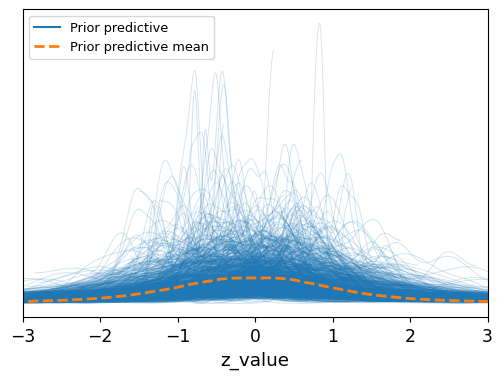

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.702,0.307,-1.231,-0.077,0.019,0.029,483.0,135.0,1.01
alpha_raw[BP],-0.367,0.820,-1.847,1.273,0.015,0.010,2923.0,4801.0,1.00
alpha_raw[HC],-0.411,0.844,-1.999,1.198,0.015,0.010,2925.0,4667.0,1.00
b[region[T.unimodal]],-0.144,0.128,-0.390,0.092,0.002,0.001,4120.0,5021.0,1.00
b[Group[T.HC]],-0.090,0.202,-0.419,0.360,0.006,0.005,1255.0,297.0,1.00
b[Sex[T.2.0]],-0.008,0.128,-0.243,0.226,0.003,0.001,1380.0,4273.0,1.00
b[region[T.unimodal]:Group[T.HC]],0.046,0.170,-0.265,0.373,0.003,0.002,3658.0,5917.0,1.00
b[z_age],0.054,0.066,-0.076,0.170,0.001,0.001,2457.0,3576.0,1.00
skew_raw[BP],2.888,0.672,1.653,4.209,0.020,0.020,1145.0,299.0,1.00
skew_raw[HC],2.663,0.687,1.192,3.843,0.023,0.018,910.0,184.0,1.00


In [31]:
import matplotlib.pyplot as plt
import arviz as az
with model:
    prior_pred = pm.sample_prior_predictive(samples=1000, random_seed=123)

az.plot_ppc(
    prior_pred,
    group="prior",          # <-- important: use prior, not posterior
    data_pairs={"z_value": "z_value"},  # map model var -> observed name (often auto)
    kind="kde",             # or "hist"
    figsize=(6,4)
)
plt.xlim(-3, 3)  # Adjust limits based on your data range
plt.show()

az.summary(trace)

In [32]:
import arviz as az

# Extract the posterior samples
alpha_posterior = trace.posterior["alpha"]  # shape: (chains, draws, group)

# Get index for HC and BP
groups = trace.posterior["alpha"].group.values
idx_HC = list(groups).index("HC")
idx_BP = list(groups).index("BP")

# Compute the difference
alpha_diff = alpha_posterior.sel(group="HC") - alpha_posterior.sel(group="BP")

# Or if working with numpy directly:
# alpha_diff = alpha_posterior[:,:,idx_HC] - alpha_posterior[:,:,idx_BP]

# Summarize the difference
az.summary(alpha_diff, hdi_prob=0.94)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.023,0.215,-0.442,0.396,0.006,0.004,1401.0,2444.0,1.0


Sampling: [z_value]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

<Axes: xlabel='z_value'>

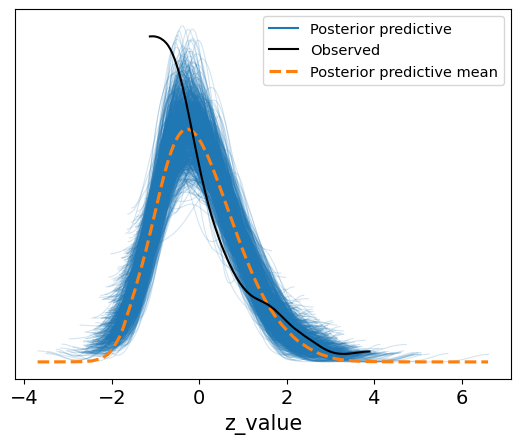

In [33]:
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["z_value"], random_seed=123)

import arviz as az

idata_ppc = trace.copy()  # this is already an InferenceData object
idata_ppc.add_groups(
    posterior_predictive=ppc.posterior_predictive  # this is an xarray.Dataset
)


az.plot_ppc(
    idata_ppc,
    group="posterior",
    data_pairs={"z_value": "z_value"},
    kind="kde",
    num_pp_samples=1000
)





In [18]:
import pandas as pd
from scipy import stats

# Define a function to run paired t-test and return t and p values
def paired_ttest(group_df):
    t_stat, p_value = stats.ttest_rel(group_df["tau_unimodal"], group_df["tau_transmodal"])
    return pd.Series({"t": t_stat, "p": p_value})

# Apply within each group
results = df_metrics.groupby("Group").apply(paired_ttest)

print(results)


              t         p
Group                    
BP    -1.707088  0.096186
HC     0.720425  0.476494


C:\Users\kaank\AppData\Local\Temp\ipykernel_21896\3309889487.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_metrics.groupby("Group").apply(paired_ttest)


In [35]:
from scipy import stats
import pandas as pd

# Independent t-test for unimodal
group1_uni = df_metrics[df_metrics["Group"] == "HC"]["tau_unimodal"]
group2_uni = df_metrics[df_metrics["Group"] == "BP"]["tau_unimodal"]
t_uni, p_uni = stats.ttest_ind(group1_uni, group2_uni, equal_var=False)

# Independent t-test for transmodal
group1_trans = df_metrics[df_metrics["Group"] == "HC"]["tau_transmodal"]
group2_trans = df_metrics[df_metrics["Group"] == "BP"]["tau_transmodal"]
t_trans, p_trans = stats.ttest_ind(group1_trans, group2_trans, equal_var=False)

# Print results
print(f"Unimodal comparison: t = {t_uni:.3f}, p = {p_uni:.3f}")
print(f"Transmodal comparison: t = {t_trans:.3f}, p = {p_trans:.3f}")


Unimodal comparison: t = 0.291, p = 0.772
Transmodal comparison: t = -1.175, p = 0.244


In [31]:

from pathlib import Path

# --- Paths ---
ctrl_path = Path(r"/Users/kaankeskin/projects/FrequencySliding/data/raw")
ctrl_csv = ctrl_path / "controlregions.csv"
# --- Read CSV ---
# We'll not assume headers; we'll read and rename first two cols defensively.
ctrl_df = pd.read_csv(ctrl_csv)

subject_group_array = ["BP"] * 38 + ["HC"] * 33
region_group_array = ctrl_df["transmodal"]

df_long = df_all.reset_index().melt(id_vars='subject', var_name='region', value_name='value')
df_long['region'] = df_long['region'].astype(int)  # convert column names to integers
df_long['subject_group'] = [subject_group_array[i] for i in df_all.index.get_indexer(df_long['subject'])]
df_long['region_group'] = df_long['region'].map(lambda i: region_group_array[i])


def zscore(s): return (s - s.mean(skipna=True)) / s.std(ddof=0,skipna=True)
df_long["z_value"] = zscore(df_long["value"])

# To be sure 
df_long["subject_group"] = df_long["subject_group"].astype("category")
df_long["subject"] = df_long["subject"].astype("category")
df_long["region_group"] = df_long["region_group"].astype("category")

df_long=df_long.dropna()
print(df_long)

print(df_long["z_value"].describe())
print(df_long["z_value"].isna().sum())
print(df_long["z_value"].nunique())

              subject  region     value subject_group region_group   z_value
0       sub-1.results       0  0.146558            BP            0 -0.143605
1      sub-10.results       0  0.082327            BP            0 -0.491374
3      sub-12.results       0  0.086344            BP            0 -0.469627
4      sub-13.results       0  0.454147            BP            0  1.521791
5      sub-15.results       0  0.085785            BP            0 -0.472652
...               ...     ...       ...           ...          ...       ...
25555  sub-71.results     359  0.078658            HC            1 -0.511243
25556  sub-72.results     359  0.082891            HC            1 -0.488323
25557  sub-73.results     359  0.081633            HC            1 -0.495134
25558  sub-74.results     359  0.086452            HC            1 -0.469040
25559  sub-75.results     359  0.083167            HC            1 -0.486825

[17597 rows x 6 columns]
count    1.759700e+04
mean    -6.460581e-18
std   

Below it is long version, that without per subject regions are not aggregated. However, it is heavily tailed, and doesnt work

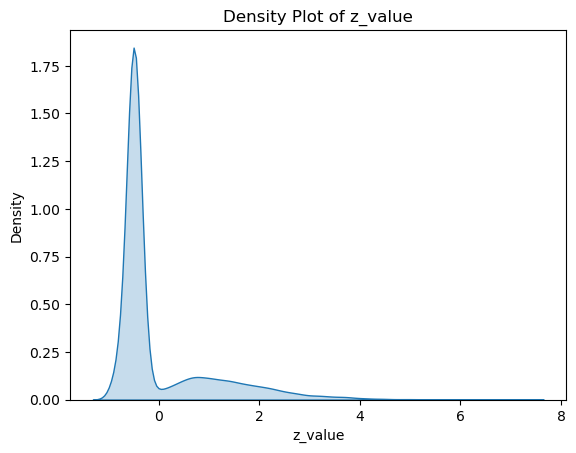

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_long, x="z_value", fill=True)
plt.title("Density Plot of z_value")
plt.xlabel("z_value")
plt.ylabel("Density")
plt.show()

Sampling: [Intercept, region_group, sigma, subject_group, subject_group:region_group, z_value]


py
0.15.0


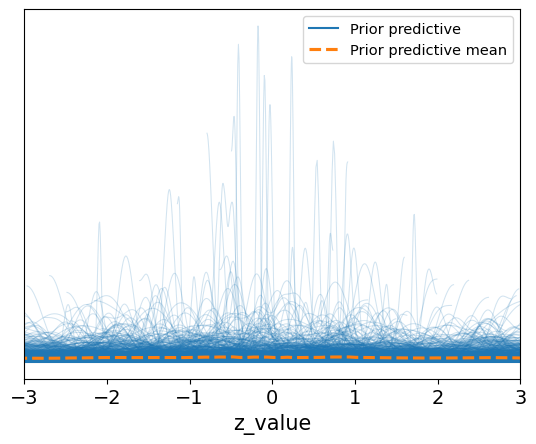

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, subject_group, region_group, subject_group:region_group]


/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/pytensor/scalar/basic.py:3191: RuntimeWarning: overflow encountered in exp
  return np.exp(x)
/opt/anaconda3/envs/bayesian/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **pass

ValueError: Not enough samples to build a trace.

In [36]:
#import os
#os.environ["PYTENSOR_FLAGS"] = "mode=FAST_RUN,linker=py,cxx="
import pytensor
print(pytensor.config.linker)

import arviz as az
import bambi as bmb
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import xarray as xr
 

priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=0.5),
    "b": bmb.Prior("Normal", mu=0, sigma=0.25),
    "sd": bmb.Prior("Exponential", lam=2),
    "sigma": bmb.Prior("Exponential", lam=2)
}

model = bmb.Model(
    "z_value ~ subject_group * region_group",
    df_long,
    priors=priors,
)
model.build()
prior_predictive = model.prior_predictive(draws=1000)
az.plot_ppc(prior_predictive, group="prior", num_pp_samples=1000)
# Set x-axis limits
plt.xlim(-3, 3)  # Adjust limits based on your data range
plt.show()
posterior = model.fit(draws=2000, tune=2000, chains=4, priors=priors, cores=4, target_accept=0.9, random_seed=123)

This is for classification success. It is also pretty bad around 0.585

In [40]:
df_cls=df_metrics.copy()
df_cls["z_transmodal"]=zscore(df_cls["tau_transmodal"])
df_cls["z_unimodal"]=zscore(df_cls["tau_transmodal"])
df_cls["z_age"]=zscore(df_cls["Age"])
df_cls["Sex"]=df_cls["Sex"].astype("category")
df_cls["Group"]=df_cls["Group"].astype("category")

X=df_cls[["z_transmodal", "z_unimodal", "z_age", "Sex"]].copy()
X["interaction"] = df_cls["z_unimodal"] * df_cls["z_transmodal"]
df_cls["Group"] = df_cls["Group"].map({"BP": 1, "HC": 0}).astype(int)
y = df_cls["Group"].values
X_array = X.values

print(y)
print(X_array)


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[[ 5.58455161e-01  5.58455161e-01  1.71524412e+00  2.00000000e+00
   3.11872167e-01]
 [-7.80764934e-01 -7.80764934e-01 -1.03586279e+00  2.00000000e+00
   6.09593883e-01]
 [-1.03621967e-01 -1.03621967e-01  1.53183699e+00  1.00000000e+00
   1.07375121e-02]
 [ 4.19955025e-01  4.19955025e-01  2.47987102e-01  1.00000000e+00
   1.76362223e-01]
 [ 2.78369522e+00  2.78369522e+00  1.34842987e+00  2.00000000e+00
   7.74895910e+00]
 [ 5.22998015e-01  5.22998015e-01 -1.31097348e+00  2.00000000e+00
   2.73526924e-01]
 [-2.65049537e-01 -2.65049537e-01 -5.77344972e-01  1.00000000e+00
   7.02512571e-02]
 [ 5.58099792e-02  5.58099792e-02 -1.67778774e+00  2.00000000e+00
   3.11475378e-03]
 [ 2.40976714e+00  2.40976714e+00 -6.69048536e-01  1.00000000e+00
   5.80697767e+00]
 [-4.55718825e-01 -4.55718825e-01 -6.69048536e-01  2.00000000e+00
   2.07679647e-01]
 [-9.

In [41]:
coords = {"obs": np.arange(len(y)), "predictor": X.columns}

with pm.Model(coords=coords) as cls_model:
    # Priors
    intercept = pm.Normal("Intercept", mu=0, sigma=1.0)
    beta = pm.Normal("b", mu=0, sigma=1.0, dims="predictor")

    # Linear model
    logits = intercept + pt.dot(X_array, beta)

    # Likelihood
    pm.Bernoulli("Group", logit_p=logits, observed=y, dims="obs")

    # Sampling
    trace_cls = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=2025)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, b]


c:\Users\kaank\miniconda3\envs\pymc\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 52 seconds.


In [46]:
import numpy as np
import arviz as az
from scipy.special import expit
from sklearn.metrics import roc_auc_score

# Extract posterior samples
posterior = trace_cls.posterior
intercept_samples = posterior["Intercept"].values.reshape(-1, 1)           # shape: (samples, 1)
beta_samples = posterior["b"].values.reshape(-1, X_array.shape[1])        # shape: (samples, features)

# Compute predicted logits and probabilities
logits = intercept_samples + beta_samples @ X_array.T                     # shape: (samples, observations)
probs = expit(logits)                                                    # sigmoid → probabilities

# Average probabilities over posterior draws
mean_probs = probs.mean(axis=0)                                          # shape: (observations,)

# True labels
y_binary = y  # or "HC" depending on your coding

print("Unique labels in y:", np.unique(y))
print("Binary labels:", np.unique(y_binary))

# Compute AUC
auc = roc_auc_score(y_binary, mean_probs)
print(f"AUC: {auc:.3f}")


Unique labels in y: [0 1]
Binary labels: [0 1]
AUC: 0.585
